# Getting Started: Market Research
This Jupyter notebook is a quick demonstration on how to get started on the market research section.

## 1) Download Data
Please download the train and test data and place it within the ./research/data path. If you've placed it in the correct place, you should see the following cell work:

In [41]:
import pandas as pd
import seaborn as sns
import numpy as np
import lightgbm as lgb
from statsmodels.tsa.stattools import acf
from sklearn.model_selection import TimeSeriesSplit,KFold,RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV,Ridge,Lasso
from sklearn.ensemble import HistGradientBoostingRegressor





train_data = pd.read_csv('/Users/jandh/Desktop/Old Desktop/od/Summer/quantchallenge-starter/train.csv')
test_data = pd.read_csv('/Users/jandh/Desktop/Old Desktop/od/Summer/quantchallenge-starter/test.csv')

# print(train_data.head())
# print(test_data.head())

## 2) Investigate the Dataset
In the datasets, you're given columns of time and A through N, each of which represent some sort of real-life market quantity. In the train dataset, you're also given Y1 and Y2, real-life market quantities you'd like to predict in terms of time and A through N. You're not given Y1 and Y2 in the test set, because this is what you're being asked to predict.

Let's do some exploration of the relationships of A - N and Y1. In particular, let's look at the relationship between C and Y1:

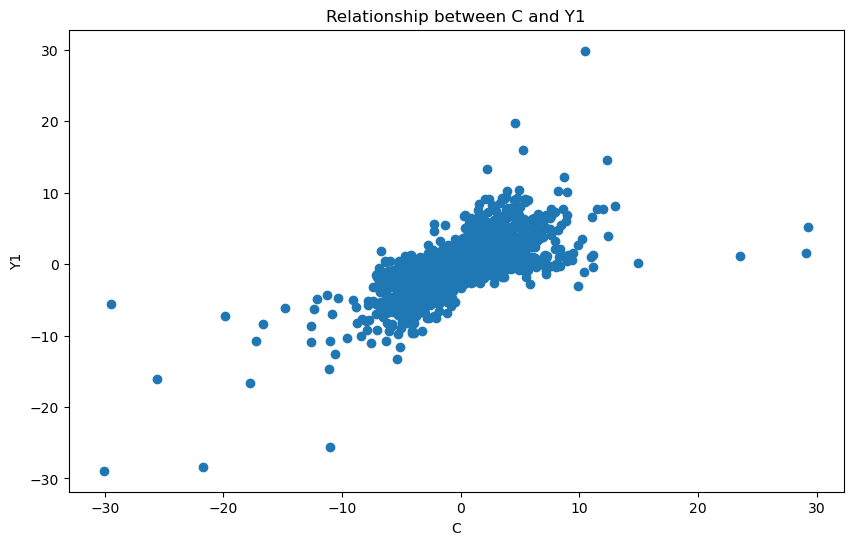

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(train_data['C'], train_data['Y1'])
plt.xlabel('C')
plt.ylabel('Y1')
plt.title('Relationship between C and Y1')
plt.show()

In [43]:
# Calculate correlation between C and Y1
correlation = train_data['C'].corr(train_data['Y1'])
print(f"Correlation between C and Y1: {correlation:.4f}")

Correlation between C and Y1: 0.7038


## Correlations

<Axes: >

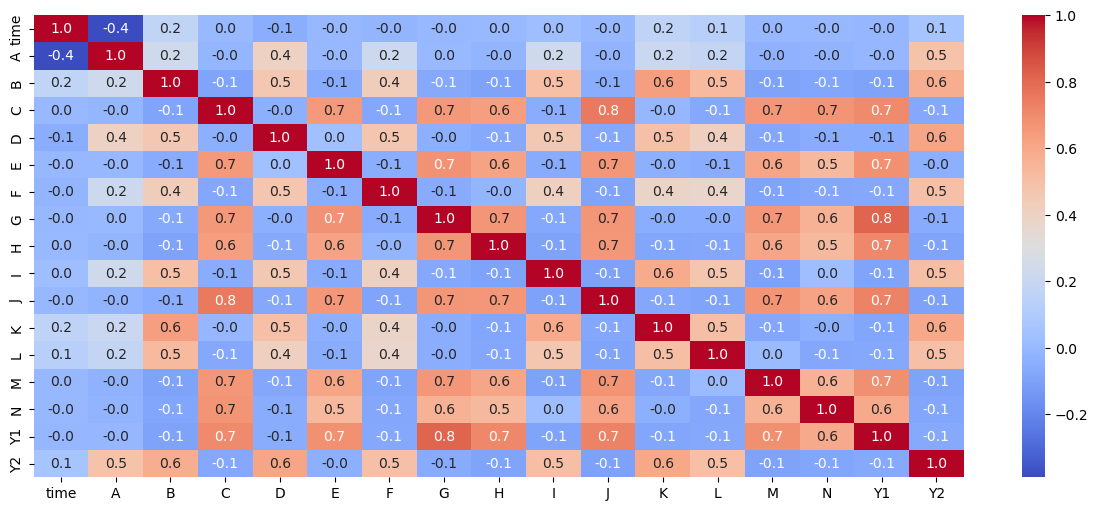

In [44]:
plt.figure(figsize=(15,6))
sns.heatmap(train_data.corr(),annot=True,cmap='coolwarm',fmt='.1f')

## Divide features into 2 categories (obtained based on below analysis)

## Y1 = f(C,E,G,H,J,M,N)
## Y2 = f(A,B,D,F,I,K,L)

In [45]:
vol_input_columns = ['A','B','D','F','I','K','L']
return_input_columns = ['C','E','G','H','J','M','N']

In [46]:
input_columns = [chr(i) for i in range(65,79)]
output_columns = ['Y1','Y2']
# input_columns

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

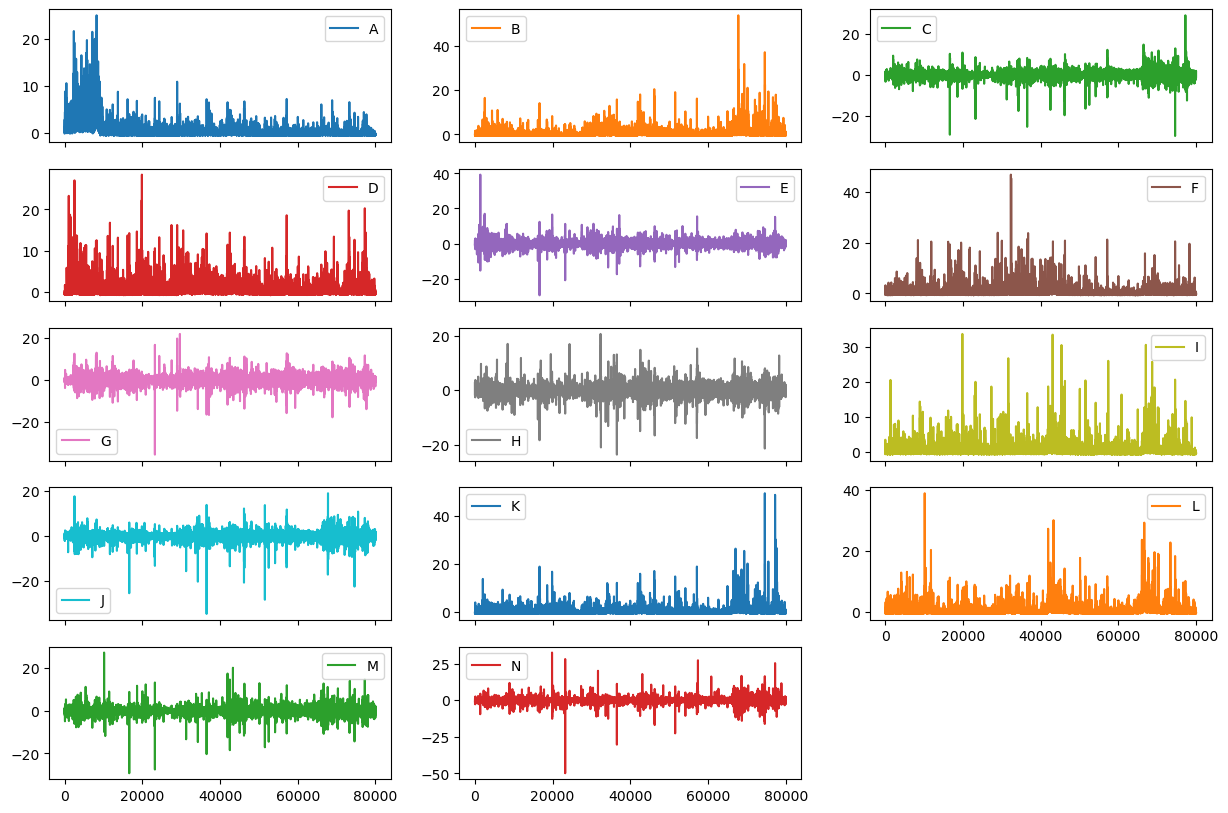

In [47]:
train_data[input_columns].plot(subplots=True,layout=(5,3),figsize=(15,10))

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

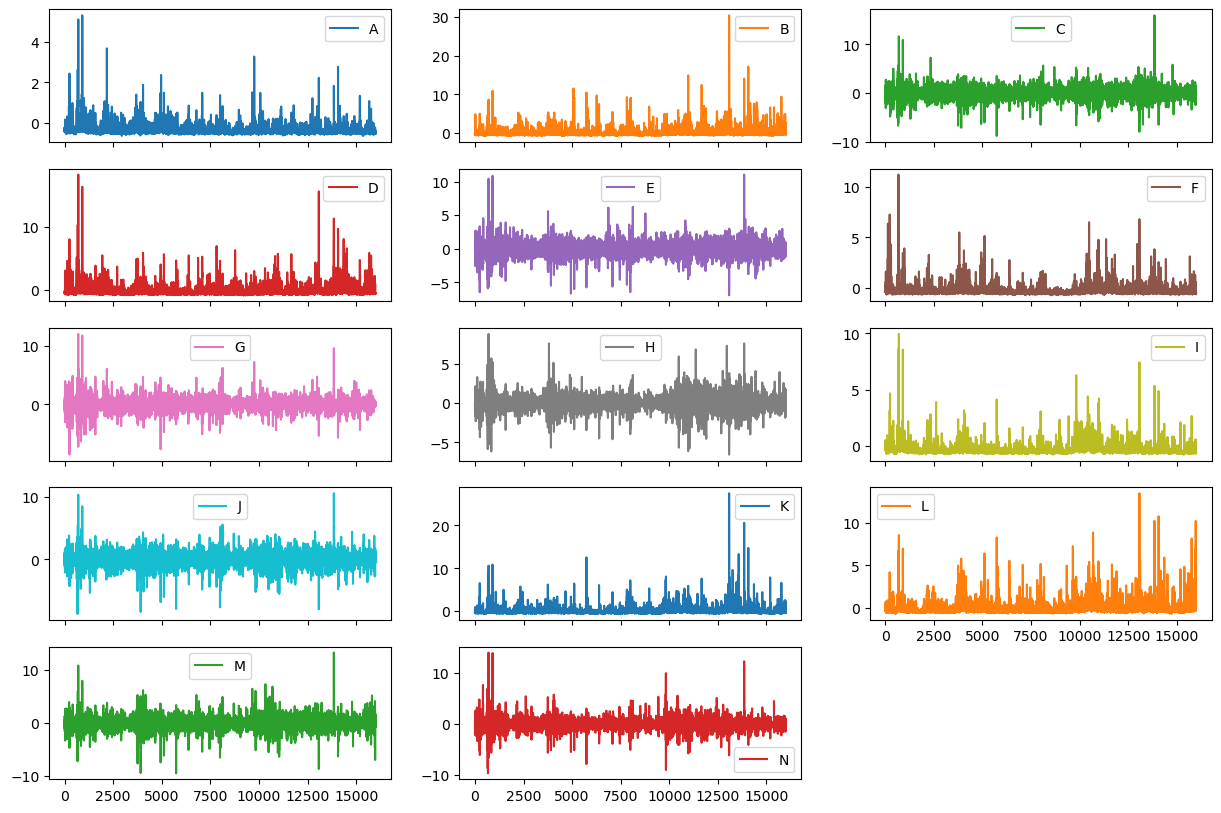

In [48]:
test_data[input_columns].plot(subplots=True,layout=(5,3),figsize=(15,10))

## Basic stats

In [49]:
train_data[input_columns].describe()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,0.068979,-0.004927,-0.000802,0.031913,-0.000292,0.063241,-0.000050,-0.002554,0.070158,-0.000028,-0.000803,0.018752,-0.000636,0.000849
std,1.078271,1.031053,1.010158,1.047274,1.036233,1.069182,1.036270,1.040708,1.064972,1.015265,1.038007,1.057857,1.012744,1.025396
min,-0.642788,-0.771179,-30.068210,-0.899105,-29.530710,-0.737694,-35.715053,-23.598892,-0.762271,-34.806015,-0.729140,-0.734872,-29.342481,-49.869913
25%,-0.374171,-0.451919,-0.417830,-0.500604,-0.475700,-0.415164,-0.419804,-0.437469,-0.395450,-0.432185,-0.405350,-0.438401,-0.386474,-0.366045
50%,-0.264501,-0.285350,-0.003942,-0.279073,-0.006753,-0.236990,-0.004954,0.006673,-0.186564,0.003981,-0.263940,-0.292186,0.004210,0.005000
75%,0.005451,0.061020,0.414435,0.166928,0.458875,0.132404,0.421969,0.444982,0.160427,0.437449,0.033419,0.055187,0.387407,0.367437
max,24.917549,53.667013,29.312756,28.490356,39.322300,46.837612,22.023252,20.634973,33.604551,19.117766,49.278617,38.849874,27.179463,32.488227


In [50]:
test_data[input_columns].describe()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
count,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000,15996.000000
mean,-0.344981,0.024641,0.004011,-0.159605,0.001462,-0.316284,0.000250,0.012773,-0.350877,0.000138,0.004014,-0.093784,0.003179,-0.004247
std,0.209108,0.827016,0.947616,0.696773,0.794427,0.405108,0.794191,0.764487,0.425857,0.919925,0.782746,0.627764,0.933715,0.861885
min,-0.649365,-0.766451,-8.826122,-0.801836,-6.930988,-0.746317,-8.526117,-6.563153,-0.782239,-8.767837,-0.659924,-0.718685,-9.525321,-9.620394
25%,-0.447109,-0.380156,-0.496147,-0.511393,-0.423642,-0.504792,-0.381212,-0.344783,-0.549627,-0.507032,-0.360237,-0.413917,-0.481297,-0.425479
50%,-0.390926,-0.196843,-0.002579,-0.352419,0.006520,-0.420138,-0.010105,0.016656,-0.459732,-0.001713,-0.201374,-0.271054,0.003691,-0.014177
75%,-0.310533,0.140340,0.510390,-0.056195,0.426623,-0.268043,0.374877,0.381378,-0.302563,0.519238,0.082748,-0.007783,0.489578,0.409030
max,5.309621,30.422147,15.984902,18.323820,11.050383,11.216073,11.994096,8.785265,9.958186,10.620093,27.532543,13.474217,13.339130,13.952276


## Outliers

In [51]:
train_data[input_columns].quantile([0.01,0.05, 0.1, 0.15,0.25,0.5,0.75,0.85,0.9,0.95,0.99])

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
0.01,-0.519694,-0.630681,-2.766209,-0.734813,-2.724341,-0.606804,-2.951903,-2.938779,-0.630160,-2.732891,-0.577078,-0.600292,-2.835162,-2.765039
0.05,-0.467365,-0.572999,-1.362769,-0.662067,-1.451671,-0.544826,-1.421151,-1.477458,-0.559669,-1.427163,-0.519540,-0.546582,-1.377953,-1.270638
0.10,-0.436371,-0.535982,-0.928534,-0.613356,-1.006342,-0.504378,-0.947118,-0.986461,-0.511105,-0.973627,-0.483267,-0.511735,-0.901308,-0.829540
0.15,-0.413856,-0.505930,-0.696175,-0.573700,-0.769907,-0.472986,-0.705968,-0.734884,-0.471268,-0.730927,-0.455167,-0.485296,-0.663664,-0.616592
0.25,-0.374171,-0.451919,-0.417830,-0.500604,-0.475700,-0.415164,-0.419804,-0.437469,-0.395450,-0.432185,-0.405350,-0.438401,-0.386474,-0.366045
0.50,-0.264501,-0.285350,-0.003942,-0.279073,-0.006753,-0.236990,-0.004954,0.006673,-0.186564,0.003981,-0.263940,-0.292186,0.004210,0.005000
0.75,0.005451,0.061020,0.414435,0.166928,0.458875,0.132404,0.421969,0.444982,0.160427,0.437449,0.033419,0.055187,0.387407,0.367437
0.85,0.408410,0.395529,0.695553,0.572964,0.755739,0.497058,0.714897,0.735623,0.474041,0.731813,0.327327,0.420412,0.656152,0.607100
0.90,0.884513,0.723089,0.931030,0.949170,1.001798,0.848815,0.960360,0.979096,0.770466,0.973361,0.625445,0.784562,0.875704,0.815052
0.95,1.777261,1.416519,1.389962,1.685068,1.455413,1.606698,1.431545,1.429929,1.433271,1.427962,1.303678,1.545785,1.333974,1.247256


In [52]:
test_data[input_columns].quantile([0.01,0.05, 0.1, 0.15,0.25,0.5,0.75,0.85,0.9,0.95,0.99])

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
0.01,-0.554009,-0.592197,-2.469617,-0.707779,-2.027286,-0.635236,-2.092161,-2.112764,-0.688324,-2.422675,-0.549016,-0.583707,-2.480614,-2.313526
0.05,-0.513119,-0.523733,-1.417944,-0.644051,-1.188111,-0.588875,-1.126584,-1.140843,-0.636364,-1.402605,-0.486330,-0.526629,-1.384554,-1.214938
0.10,-0.490061,-0.477690,-1.009828,-0.600701,-0.849876,-0.560503,-0.795199,-0.779598,-0.606992,-1.018162,-0.445717,-0.493770,-0.978740,-0.854282
0.15,-0.473021,-0.441785,-0.791910,-0.567365,-0.662736,-0.539219,-0.613134,-0.596020,-0.586788,-0.802302,-0.414940,-0.464687,-0.765410,-0.663664
0.25,-0.447109,-0.380156,-0.496147,-0.511393,-0.423642,-0.504792,-0.381212,-0.344783,-0.549627,-0.507032,-0.360237,-0.413917,-0.481297,-0.425479
0.50,-0.390926,-0.196843,-0.002579,-0.352419,0.006520,-0.420138,-0.010105,0.016656,-0.459732,-0.001713,-0.201374,-0.271054,0.003691,-0.014177
0.75,-0.310533,0.140340,0.510390,-0.056195,0.426623,-0.268043,0.374877,0.381378,-0.302563,0.519238,0.082748,-0.007783,0.489578,0.409030
0.85,-0.241295,0.433382,0.817026,0.200494,0.670784,-0.136899,0.616748,0.616579,-0.159685,0.827958,0.351465,0.226828,0.783822,0.657872
0.90,-0.175603,0.705703,1.040523,0.441806,0.848238,-0.015884,0.811293,0.807644,-0.029154,1.035990,0.589940,0.443663,1.007378,0.858987
0.95,-0.039045,1.245602,1.430831,0.924847,1.177022,0.246376,1.157543,1.132124,0.252804,1.394600,1.116242,0.895118,1.401414,1.215322


## prediction columns

array([[<Axes: >],
       [<Axes: >]], dtype=object)

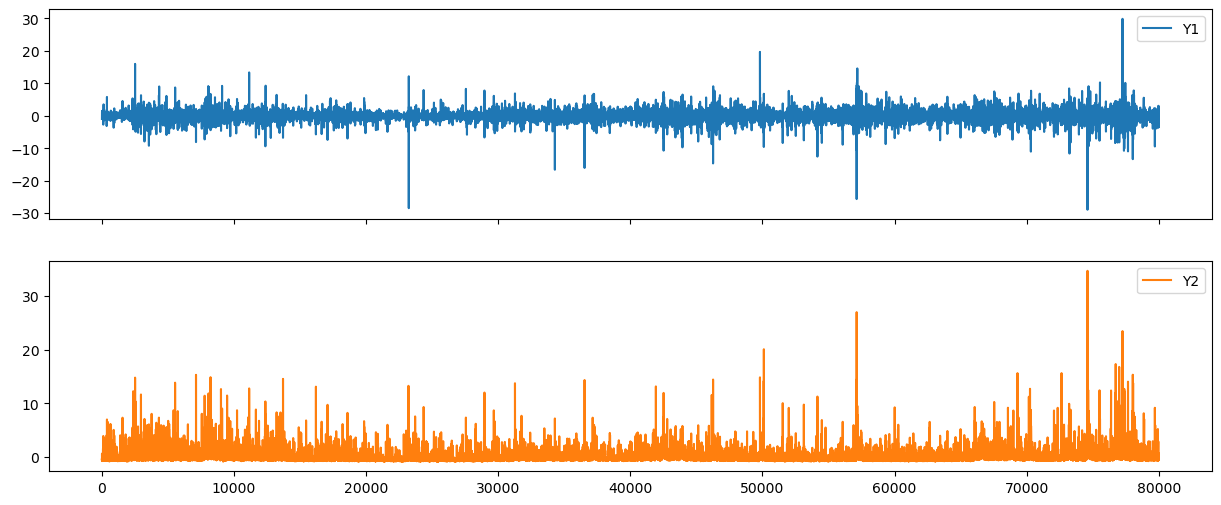

In [53]:
train_data[output_columns].plot(subplots=True,layout=(2,1),figsize=(15,6))

#### Looks like returns and vol

Checking correlation structure changes in train and test

In [54]:
train_data[input_columns].corr()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
A,1.000000,0.234165,-0.014099,0.401397,-0.001812,0.213891,0.004653,-0.017072,0.233219,-0.024575,0.206646,0.181888,-0.027864,-0.022795
B,0.234165,1.000000,-0.087635,0.463441,-0.060270,0.425797,-0.065093,-0.093476,0.500890,-0.052194,0.634238,0.526446,-0.095832,-0.085115
C,-0.014099,-0.087635,1.000000,-0.040376,0.651873,-0.076914,0.657781,0.636027,-0.055286,0.755029,-0.005060,-0.070583,0.662659,0.672503
D,0.401397,0.463441,-0.040376,1.000000,0.037757,0.469741,-0.044049,-0.064194,0.458717,-0.069936,0.495356,0.419148,-0.076082,-0.054570
E,-0.001812,-0.060270,0.651873,0.037757,1.000000,-0.052012,0.677760,0.616605,-0.059943,0.661936,-0.038899,-0.055095,0.613281,0.529844
F,0.213891,0.425797,-0.076914,0.469741,-0.052012,1.000000,-0.059259,-0.019917,0.409510,-0.089096,0.383416,0.371881,-0.087894,-0.076666
G,0.004653,-0.065093,0.657781,-0.044049,0.677760,-0.059259,1.000000,0.668732,-0.072203,0.665985,-0.049647,-0.047391,0.660633,0.561462
H,-0.017072,-0.093476,0.636027,-0.064194,0.616605,-0.019917,0.668732,1.000000,-0.092602,0.661407,-0.082067,-0.075921,0.614654,0.532252
I,0.233219,0.500890,-0.055286,0.458717,-0.059943,0.409510,-0.072203,-0.092602,1.000000,-0.097424,0.589646,0.468341,-0.096249,0.027320
J,-0.024575,-0.052194,0.755029,-0.069936,0.661936,-0.089096,0.665985,0.661407,-0.097424,1.000000,-0.078695,-0.089647,0.670946,0.614869


In [55]:
test_data[input_columns].corr()

,A,B,C,D,E,F,G,H,I,J,K,L,M,N
A,1.000000,0.494053,0.004123,0.653423,0.002539,0.464109,0.030294,-0.021499,0.591588,0.010381,0.512624,0.529663,0.002815,0.016443
B,0.494053,1.000000,-0.069628,0.639579,-0.076922,0.477063,-0.058915,-0.087456,0.594252,-0.070611,0.676738,0.660486,-0.075544,-0.057863
C,0.004123,-0.069628,1.000000,-0.022423,0.803639,-0.032536,0.747725,0.708714,-0.023229,0.845548,-0.030223,-0.050841,0.837067,0.826977
D,0.653423,0.639579,-0.022423,1.000000,0.001243,0.500665,-0.022219,-0.048550,0.632882,-0.026969,0.653698,0.642008,-0.028435,-0.023839
E,0.002539,-0.076922,0.803639,0.001243,1.000000,-0.042723,0.770682,0.697018,-0.035765,0.789553,-0.051954,-0.056802,0.801955,0.755930
F,0.464109,0.477063,-0.032536,0.500665,-0.042723,1.000000,-0.033370,-0.002415,0.500955,-0.041442,0.479840,0.510278,-0.045505,-0.024073
G,0.030294,-0.058915,0.747725,-0.022219,0.770682,-0.033370,1.000000,0.664689,-0.023925,0.734787,-0.044870,-0.049879,0.747644,0.735849
H,-0.021499,-0.087456,0.708714,-0.048550,0.697018,-0.002415,0.664689,1.000000,-0.055817,0.713013,-0.067632,-0.065139,0.710405,0.669647
I,0.591588,0.594252,-0.023229,0.632882,-0.035765,0.500955,-0.023925,-0.055817,1.000000,-0.035260,0.662962,0.634121,-0.036066,0.013730
J,0.010381,-0.070611,0.845548,-0.026969,0.789553,-0.041442,0.734787,0.713013,-0.035260,1.000000,-0.049753,-0.053324,0.835392,0.781557


In [56]:
def frob_norm_similarity(A,B,normalize=True):
    p = A.shape[0]
    iu = np.triu_indices(p,1)
    d = A[iu] - B[iu]
    val = np.linalg.norm(d)
    return val / np.sqrt(len(iu[0])) if normalize else val

In [57]:
frob_norm_similarity(train_data[input_columns].corr().values,test_data[input_columns].corr().values)

0.1166709091004106

In [58]:
from scipy.stats import chi2
def jennrich_test(A,B,n1,n2,eps = 1e-9):
    p = A.shape[0]
    iu = np.triu_indices(p,1)
    r1 = np.clip(A[iu],-1+eps,1-eps)
    r2 = np.clip(B[iu],-1+eps,1-eps)
    z1,z2 = np.arctanh(r1) , np.arctanh(r2)
    var = 1.0/ (n1-3) + 1.0/(n2-3)
    J = np.sum((z1-z2)**2 / var)
    print((z1-z2)**2)
    df = (p * (p-1)) //2
    pval = 1 - chi2.cdf(J,df)
    return J,df,pval


In [59]:
jennrich_test(train_data[input_columns].corr().values,test_data[input_columns].corr().values,train_data.shape[0],test_data.shape[0])

[9.16978925e-02 3.32095116e-04 1.26690115e-01 1.89246707e-05
 8.13899611e-02 6.57934619e-04 1.96140350e-05 1.95818530e-01
 1.22226588e-03 1.27175440e-01 1.64627072e-01 9.41586122e-04
 1.54003458e-03 3.28324084e-04 6.54218916e-02 2.79940472e-04
 4.15023239e-03 3.84598713e-05 3.68386221e-05 1.78811791e-02
 3.41766116e-04 5.56468133e-03 4.34549227e-02 4.17723210e-04
 7.50412374e-04 3.22994402e-04 1.09067596e-01 1.98186859e-03
 3.19988448e-02 1.77215725e-02 1.03094365e-03 6.54198285e-02
 6.33609468e-04 3.92652332e-04 1.71192346e-01 1.31913463e-01
 1.33463654e-03 1.63668332e-03 4.77646057e-04 2.46334349e-04
 6.27618071e-02 1.85547040e-03 5.69275763e-02 9.91764509e-02
 2.28357436e-03 9.47475499e-04 8.66793286e-05 3.88277404e-02
 2.01552070e-02 5.87287183e-04 7.50717425e-02 1.71127850e-04
 2.93081021e-06 1.52023290e-01 1.57388536e-01 6.73192294e-04
 3.06419587e-04 1.33534403e-02 2.29122250e-03 1.40940697e-02
 2.97566865e-02 1.81340857e-03 2.78140816e-03 5.29949536e-05
 2.34253434e-03 1.837671

(40287.586824980914, 91, 0.0)

#### Correlation structures b/w variables is changing (maybe linear methods are not ideal)

## Pred variables stats

In [60]:
train_data[output_columns].describe()

,Y1,Y2
count,80000.000000,80000.000000
mean,-0.002807,-0.061172
std,0.970655,0.923702
min,-28.918180,-0.850799
25%,-0.387523,-0.497802
50%,-0.001591,-0.318091
75%,0.392470,0.026905
max,29.859458,34.636039


### Applying returns, vol intuition , checking auto-corr, cross-corr with sqaured returns,vols etc

<StemContainer object of 3 artists>

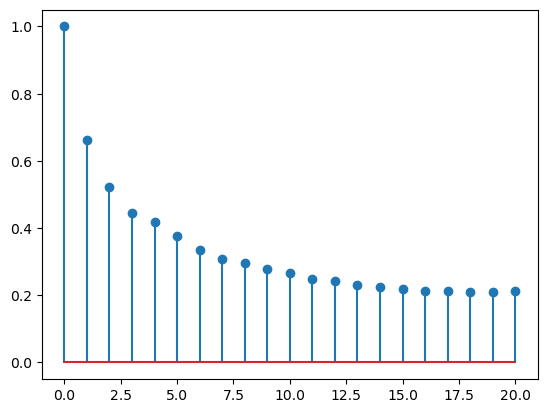

In [61]:
acf_vals = acf(train_data['Y2'],nlags = 20)
plt.stem(range(len(acf_vals)),acf_vals)

## High Auto-Correlation for Y2 (similar to vol)

In [62]:
train_data['Y1^2'] = train_data['Y1']**2

# train_data['Y2^2'] = train_data['Y2']**2



In [63]:
# plt.figure(figsize=(15,6))
# sns.heatmap(train_data.corr(),annot=True,cmap='coolwarm',fmt='.1f')
# plt.figure(figsize=(15,6))
# sns.heatmap(pd.concat([train_data[return_input_columns]**2,train_data[vol_input_columns]],axis=1).corr(),annot=True,cmap='coolwarm',fmt='.1f')
# vol_input_columns
# pairs =[['C','K'], ['E','D'], ['H','F'], ['M','L'],['N','I'] ,['J','B'] , ['G','A']]


# plt.figure(figsize=(15,6))
# sns.heatmap(train_data[train_data['Y2']<1].corr(),annot=True,cmap='coolwarm',fmt='.1f')
# # corrM = train_data[train_data['Y2']<1].corr()
# # y = 'Y2'
# # X = [col for col in input_columns if col not in ['Y2']]
# # r = corrM.loc[X,y].values.reshape(-1,1)
# # R_xx = corrM.loc[X,X].values

# # R2 = r.T @ np.linalg.inv(R_xx) @ r

# # print(f"R2 :{R2}")

In [64]:
def cross_corr(x,y,lag_max=10):
    lags = range(-lag_max,lag_max+1)
    ccs = [x.corr(y.shift(lag)) for lag in lags]
    return lags,ccs

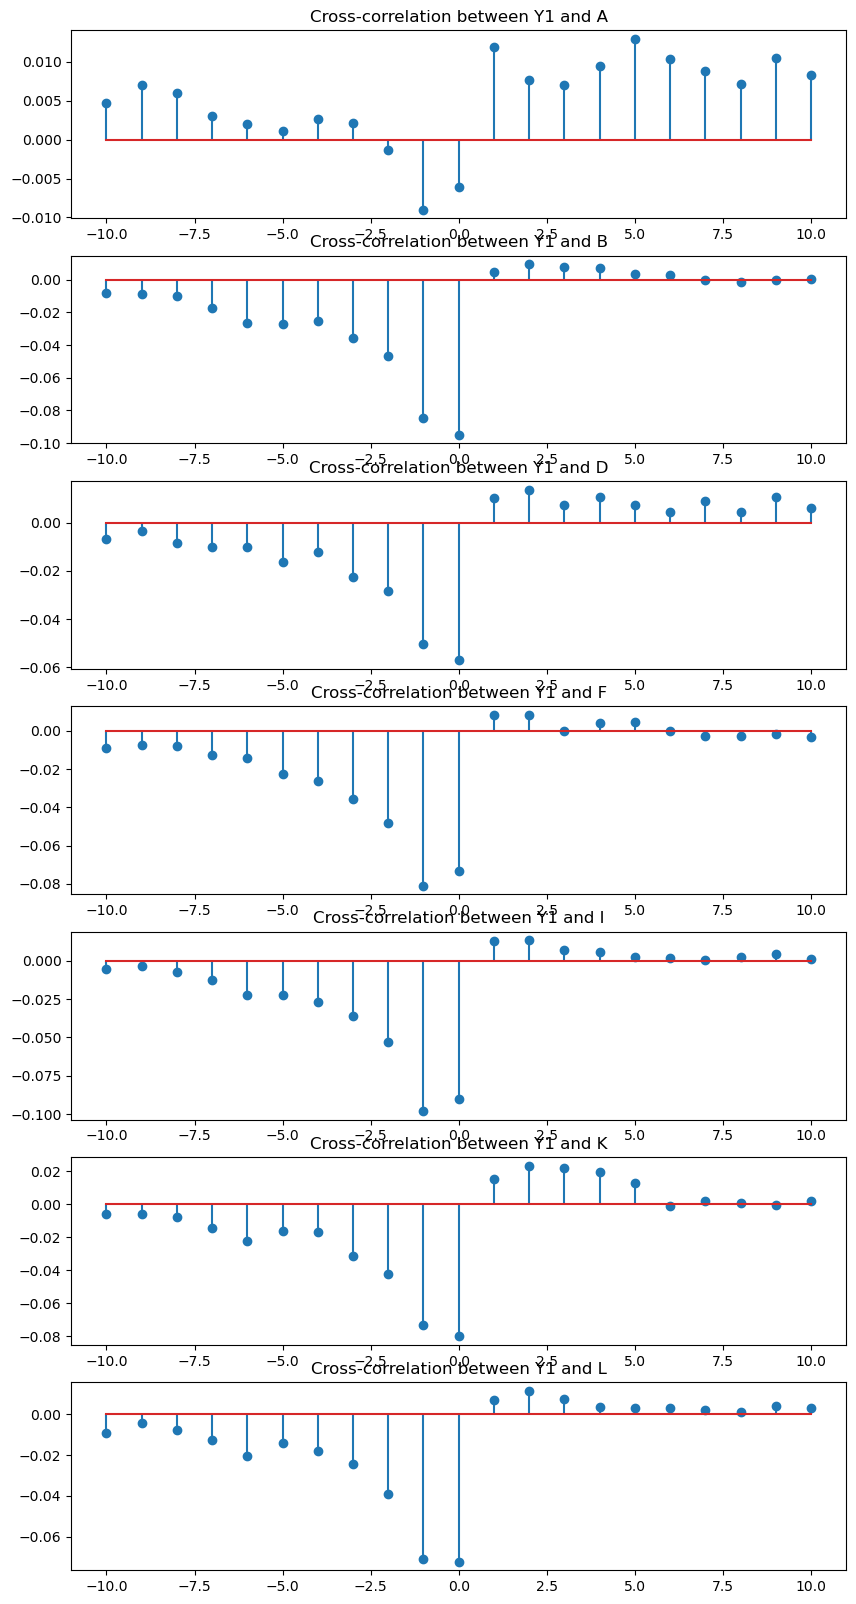

In [65]:
fig, axes = plt.subplots(len(vol_input_columns),1,figsize=(10,20))
for ax, col in zip(axes,vol_input_columns):
    lags,ccs = cross_corr(train_data['Y1'],train_data[col])
    ax.stem(lags,ccs)
    # ax.xlabel('Lag')
    ax.set_title(f'Cross-correlation between Y1 and {col}')
plt.show()
# lags,ccs = cross_corr(train_data['Y1'],train_data['C'])
# plt.stem(lags,ccs)
# plt.xlabel('Lag')
# plt.show()

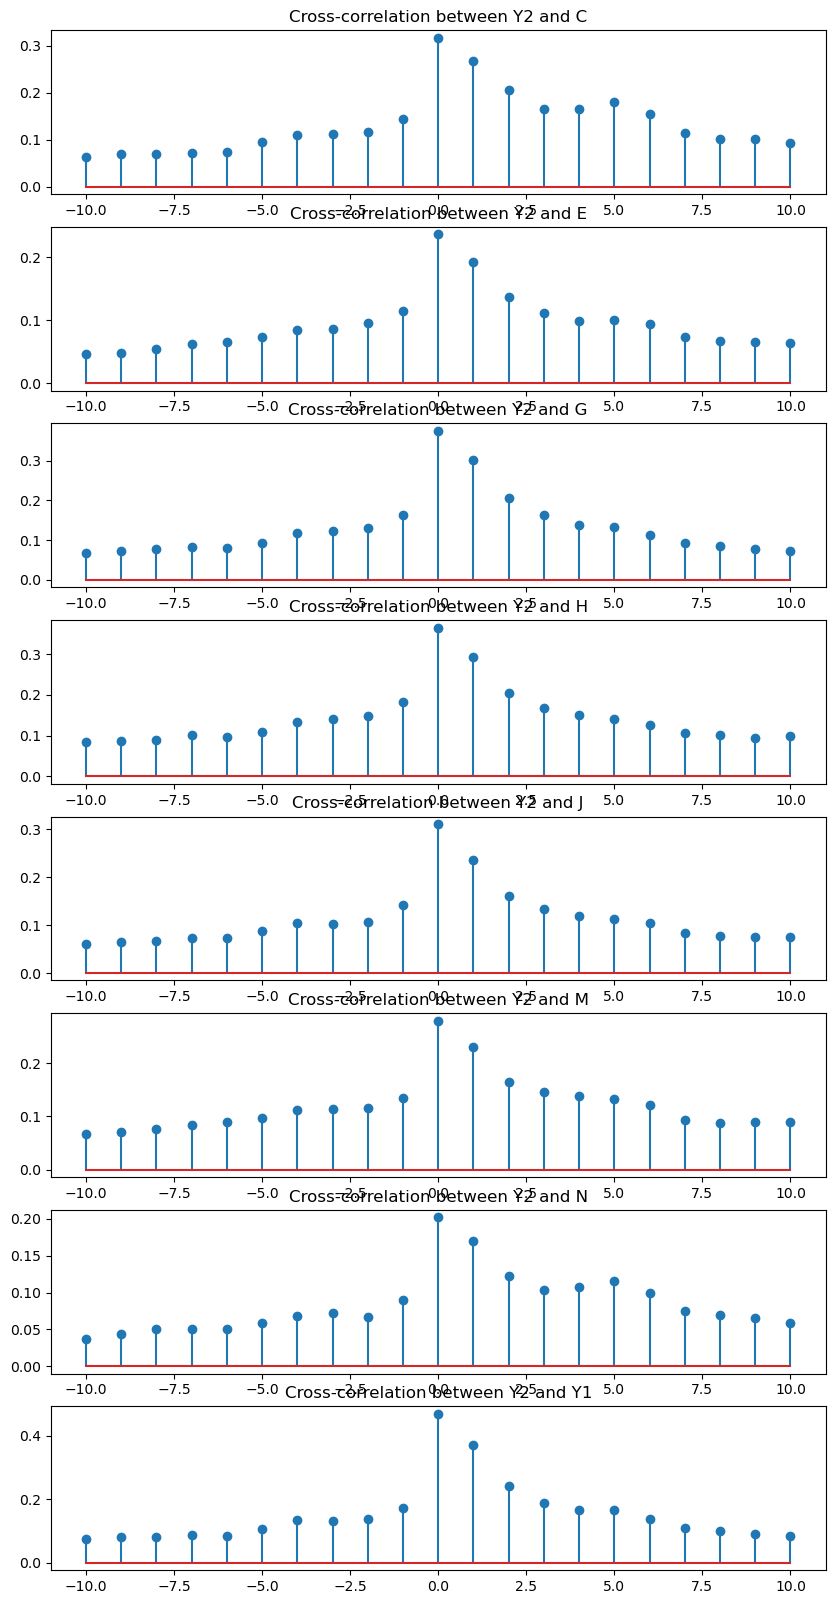

In [66]:
fig, axes = plt.subplots(len(return_input_columns)+1,1,figsize=(10,20))
for ax, col in zip(axes,return_input_columns+['Y1']):
    lags,ccs = cross_corr(train_data['Y2'],train_data[col]**2)
    ax.stem(lags,ccs)
    # ax.xlabel('Lag')
    ax.set_title(f'Cross-correlation between Y2 and {col}')
plt.show()

In [67]:
def create_input_features(columns,df,lag_dict = None):
    feature_list = []
    # print(lag_dict,'R' in lag_dict)
    for col in columns:
        feature_list.append(df[col])
        if col in return_input_columns and 'R' in lag_dict:
            for lag in range(lag_dict['R'][0],lag_dict['R'][1],1):
                if lag == 0 :
                    continue
                feature_list.append(df[col].shift(-lag).rename(f'{col}_{lag}'))

        if col in return_input_columns and 'R2' in lag_dict:
            for lag in range(lag_dict['R2'][0],lag_dict['R2'][1],1):
                # if lag == 0 :
                #     continue
                feature_list.append((df[col]**2).shift(-lag).rename(f'{col}_squared_{lag}'))
        
        
        if col in vol_input_columns and 'V' in lag_dict:
            for lag in range(lag_dict['V'][0],lag_dict['V'][1],1):
                if lag == 0 :
                    continue
                feature_list.append(df[col].shift(-lag).rename(f'{col}_{lag}'))
        
    feature_df = pd.concat(feature_list,axis=1)
    return feature_df



In [68]:
def add_time_features(df, cols, lags, rolls, make_deltas=True, make_pct=True):
    for c in cols:
        # Lags
        for lag in lags:
            df[f"{c}_lag{lag}"] = df[c].shift(lag)
        # Rolling mean/std
        for w in rolls:
            df[f"{c}_roll{w}_mean"] = df[c].rolling(w).mean()
            df[f"{c}_roll{w}_std"]  = df[c].rolling(w).std()
        # Deltas
        if make_deltas:
            df[f"{c}_d1"] = df[c] - df[c].shift(1)
            df[f"{c}_d5"] = df[c] - df[c].shift(5)
        # Percent change (to normalize level drift)
        if make_pct:
            lag1 = df[c].shift(1)
            df[f"{c}_pct1"] = (df[c] - lag1) / (lag1.abs() + 1e-6)
    return df


### Create additional temporal features for input columns, such as lagged returns, avg returns, change in returns etc (in some sense capture factors like momentum , mean-reversion etc)

In [69]:
# X_new = create_input_features(input_columns,train_data,{'V':(-5,1), 'R2': (-5,1)})


DRIFT_COLS = ["A", "I", "F", "B", "D", "K", "L"]

# Temporal features to build
LAGS       = [1, 5, 10, 20, 50]
ROLL_WIN   = [5, 10, 20, 50]
MAKE_DELTAS = True     # x - x_lag1 and x - x_lag5
MAKE_PCT    = True     

X_new = add_time_features(train_data[input_columns], DRIFT_COLS, LAGS, ROLL_WIN, MAKE_DELTAS, MAKE_PCT)


X_new.head()


# X_new = train_data[input_columns].copy()
# X_new.head()

/var/folders/vf/gw1t6f4j3mv84kp8kpw4j_bw0000gn/T/ipykernel_8687/3971992279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{c}_lag{lag}"] = df[c].shift(lag)
/var/folders/vf/gw1t6f4j3mv84kp8kpw4j_bw0000gn/T/ipykernel_8687/3971992279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{c}_lag{lag}"] = df[c].shift(lag)
/var/folders/vf/gw1t6f4j3mv84kp8kpw4j_bw0000gn/T/ipykernel_8687/3971992279.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

,A,B,C,D,E,F,G,H,I,J,...,L_roll5_std,L_roll10_mean,L_roll10_std,L_roll20_mean,L_roll20_std,L_roll50_mean,L_roll50_std,L_d1,L_d5,L_pct1
0,0.207366,-0.159951,-0.634176,-0.580962,-0.266505,0.060173,-0.475257,-1.486516,-0.332594,-0.671466,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.188828,-0.265508,0.042143,-0.550442,-0.132319,-0.185219,0.028295,0.093210,-0.518139,-0.251917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.171445,NaN,-0.913765
2,-0.144261,-0.577142,-0.214634,-0.747391,-0.184255,-0.464831,-0.085181,0.700449,-0.603438,0.197773,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.221730,NaN,-0.617512
3,0.208982,-0.310449,0.513708,-0.562868,0.742308,-0.305487,0.762246,1.363020,-0.384575,0.525556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.152700,NaN,0.262913
4,0.093320,-0.358156,0.173188,-0.687296,-0.161461,-0.116062,-0.245748,0.863372,-0.655588,-0.263358,...,0.147124,NaN,NaN,NaN,NaN,NaN,NaN,-0.053115,NaN,-0.124072


In [70]:
train_data_new = pd.concat([X_new,train_data[output_columns]],axis=1).dropna().reset_index(drop=True)

In [71]:
train_data_new.describe()

,A,B,C,D,E,F,G,H,I,J,...,L_roll10_std,L_roll20_mean,L_roll20_std,L_roll50_mean,L_roll50_std,L_d1,L_d5,L_pct1,Y1,Y2
count,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,...,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000
mean,0.068571,-0.004788,-0.000760,0.032220,-0.000255,0.063325,-0.000032,-0.002508,0.070226,0.000004,...,0.364387,0.018922,0.429328,0.018921,0.515940,0.000003,0.000008,-0.090963,-0.002809,-0.061000
std,1.078412,1.031338,1.010394,1.047516,1.036367,1.069476,1.036527,1.040689,1.065189,1.015481,...,0.563059,0.781460,0.592841,0.705535,0.606956,0.727540,1.033582,163.280640,0.970846,0.923939
min,-0.642788,-0.771179,-30.068210,-0.899105,-29.530710,-0.737694,-35.715053,-23.598892,-0.762271,-34.806015,...,0.009528,-0.591856,0.018399,-0.561875,0.044898,-18.468082,-31.088314,-38582.587777,-28.918180,-0.850799
25%,-0.374211,-0.451961,-0.417933,-0.500429,-0.475687,-0.415212,-0.419910,-0.437248,-0.395471,-0.432220,...,0.100977,-0.390150,0.127621,-0.368586,0.177553,-0.136562,-0.170507,-0.422321,-0.387563,-0.497794
50%,-0.264624,-0.285376,-0.003884,-0.278758,-0.006640,-0.237065,-0.004818,0.006686,-0.186558,0.004036,...,0.185463,-0.234998,0.238084,-0.211841,0.327500,-0.007976,-0.007412,-0.019847,-0.001549,-0.317982
75%,0.004665,0.061328,0.414542,0.167239,0.458907,0.132427,0.422006,0.444699,0.160486,0.437476,...,0.400909,0.108288,0.496220,0.125286,0.618401,0.116726,0.152065,0.291644,0.392466,0.027194
max,24.917549,53.667013,29.312756,28.490356,39.322300,46.837612,22.023252,20.634973,33.604551,19.117766,...,14.904139,13.536267,12.625163,8.586876,9.252201,28.460806,39.254419,21244.785442,29.859458,34.636039


## Remove outliers (not - necessary for trees)

In [72]:
updated_input_columns = list(train_data_new.drop(columns=['Y1','Y2']).columns)

In [73]:
combined_mask = pd.Series(True,index=train_data_new.index)
# for col in updated_input_columns + ['Y1','Y2']:
#     combined_mask = combined_mask & (train_data_new[col] < train_data_new[col].quantile(0.999)) & (train_data_new[col] > train_data_new[col].quantile(0.001))

train_data_clean = train_data_new[combined_mask].copy()

In [74]:
train_data_clean.describe()

,A,B,C,D,E,F,G,H,I,J,...,L_roll10_std,L_roll20_mean,L_roll20_std,L_roll50_mean,L_roll50_std,L_d1,L_d5,L_pct1,Y1,Y2
count,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,...,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000,79950.000000
mean,0.068571,-0.004788,-0.000760,0.032220,-0.000255,0.063325,-0.000032,-0.002508,0.070226,0.000004,...,0.364387,0.018922,0.429328,0.018921,0.515940,0.000003,0.000008,-0.090963,-0.002809,-0.061000
std,1.078412,1.031338,1.010394,1.047516,1.036367,1.069476,1.036527,1.040689,1.065189,1.015481,...,0.563059,0.781460,0.592841,0.705535,0.606956,0.727540,1.033582,163.280640,0.970846,0.923939
min,-0.642788,-0.771179,-30.068210,-0.899105,-29.530710,-0.737694,-35.715053,-23.598892,-0.762271,-34.806015,...,0.009528,-0.591856,0.018399,-0.561875,0.044898,-18.468082,-31.088314,-38582.587777,-28.918180,-0.850799
25%,-0.374211,-0.451961,-0.417933,-0.500429,-0.475687,-0.415212,-0.419910,-0.437248,-0.395471,-0.432220,...,0.100977,-0.390150,0.127621,-0.368586,0.177553,-0.136562,-0.170507,-0.422321,-0.387563,-0.497794
50%,-0.264624,-0.285376,-0.003884,-0.278758,-0.006640,-0.237065,-0.004818,0.006686,-0.186558,0.004036,...,0.185463,-0.234998,0.238084,-0.211841,0.327500,-0.007976,-0.007412,-0.019847,-0.001549,-0.317982
75%,0.004665,0.061328,0.414542,0.167239,0.458907,0.132427,0.422006,0.444699,0.160486,0.437476,...,0.400909,0.108288,0.496220,0.125286,0.618401,0.116726,0.152065,0.291644,0.392466,0.027194
max,24.917549,53.667013,29.312756,28.490356,39.322300,46.837612,22.023252,20.634973,33.604551,19.117766,...,14.904139,13.536267,12.625163,8.586876,9.252201,28.460806,39.254419,21244.785442,29.859458,34.636039


In [75]:
train_data_clean[['Y1','Y2']].describe()

,Y1,Y2
count,79950.000000,79950.000000
mean,-0.002809,-0.061000
std,0.970846,0.923939
min,-28.918180,-0.850799
25%,-0.387563,-0.497794
50%,-0.001549,-0.317982
75%,0.392466,0.027194
max,29.859458,34.636039


In [76]:

RANDOM=42
rng=np.random.RandomState(RANDOM)

In [77]:
train_data_clean.reset_index(drop=True,inplace=True)

## TS Split because the prediction period follows training period and is ordered

In [78]:
USE_TIME_SERIES=True
if USE_TIME_SERIES:
    cv=TimeSeriesSplit(n_splits=4)
else:
    cv=KFold(n_splits=5,shuffle=True,random_state=RANDOM)

In [79]:
import numpy as np
from scipy.stats import loguniform, uniform
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import xgboost as xgb

In [80]:
VAL_SIZE   = 10_000    # last-block size
PURGE_GAP  = 500       # drop rows just before validation

SEEDS_XGB  = [42, 202, 909, 131, 777]   

# SEEDS_LGB = [42]
# SEEDS_XGB = [42]

n = train_data_clean.shape[0]
val_start = n - VAL_SIZE
train_end = max(0, val_start - PURGE_GAP)
tr_idx = np.arange(0, train_end)
va_idx = np.arange(val_start, n)
print(f"[Split] Train={len(tr_idx)} | Purge={PURGE_GAP} | Valid={len(va_idx)}")

[Split] Train=69450 | Purge=500 | Valid=10000


In [81]:
# ---------------- Train base models on holdout ----------------
evals_result = {}
def train_xgb_holdout(X, y, tr_idx, va_idx, seeds, params):
    preds_val = np.zeros(len(va_idx))
    dtrain = xgb.DMatrix(X[tr_idx], y[tr_idx])
    dval = xgb.DMatrix(X[va_idx], y[va_idx])
    best_iters = []
    for sd in seeds:
        m = xgb.train(
            dict(params, seed=sd),
            dtrain,
            num_boost_round=20_000,
            evals=[[dtrain,'train'],[dval,'valid']],
            evals_result = evals_result,
            callbacks=[xgb.callback.EarlyStopping(500)],
            verbose_eval=False
        )
        preds_val += m.predict(xgb.DMatrix(X[va_idx]), iteration_range=(0, m.best_iteration + 1)) / len(seeds)
        best_iters.append(m.best_iteration)
        print("[Train : ]",evals_result['train']['rmse'][m.best_iteration-1],
              "['Test: ']",evals_result['valid']['rmse'][m.best_iteration-1],"current_seed",sd)
    return preds_val, int(np.mean(best_iters))

In [82]:
# ---------------- Train base models on holdout ----------------
def train_lgb_holdout(X, y, tr_idx, va_idx, seeds, params):
    preds_val = np.zeros(len(va_idx))
    dtrain = lgb.Dataset(X[tr_idx], y[tr_idx])
    deval  = lgb.Dataset(X[va_idx], y[va_idx])
    best_iters = []
    for sd in seeds:
        m = lgb.train(
            dict(params, seed=sd),
            dtrain,
            num_boost_round=20_000,
            valid_sets=[dtrain, deval],
            valid_names=["train", "valid"],
            callbacks=[lgb.early_stopping(500),lgb.log_evaluation(0)]
        )
        preds_val += m.predict(X[va_idx], num_iteration=m.best_iteration) / len(seeds)
        best_iters.append(m.best_iteration)
        print(m.best_score,"current_seed",sd)
    return preds_val, int(np.mean(best_iters))

In [83]:
TARGETS    = ["Y1", "Y2"]

X_all = train_data_clean[updated_input_columns].values
Y_all = train_data_clean[TARGETS].values

In [84]:
LGB_PARAMS = dict(
    objective="regression",
    metric="rmse",
    learning_rate=0.03,
    num_leaves=16,
    min_data_in_leaf=1500,
    feature_fraction=0.60,
    bagging_fraction=0.60,
    bagging_freq=1,
    lambda_l2=40.0,
    extra_trees=True,
    verbosity=-1
)

XGB_PARAMS = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    learning_rate=0.01,
    max_depth=5,
    colsample_bytree=0.50,
    subsample=0.50,
    # reg_lambda=40.0,
    tree_method="hist",
    verbosity=0,
    verbose_eval = False
)



hold_lgb = {}
best_iters_lgb = {}
hold_xgb = {}
best_iters_xgb = {}

In [9]:
for t_idx, tgt in enumerate(TARGETS):
    y = Y_all[:, t_idx]
    p_lgb, bi_lgb = train_lgb_holdout(X_all, y, tr_idx, va_idx, SEEDS_LGB, LGB_PARAMS)
    hold_lgb[tgt] = p_lgb
    best_iters_lgb[tgt] = bi_lgb


    p_xgb, bi_xgb = train_xgb_holdout(X_all, y, tr_idx, va_idx, SEEDS_LGB, XGB_PARAMS)
    hold_xgb[tgt] = p_xgb
    best_iters_xgb[tgt] = bi_xgb

    r2_lgb = r2_score(Y_all[va_idx, t_idx], hold_lgb[tgt])
    msg = f"[Holdout] {tgt} LGB R²={r2_lgb:.6f} (best_iter≈{bi_lgb})"
    r2_xgb = r2_score(Y_all[va_idx, t_idx], hold_xgb[tgt])
    msg += f" | XGB R²={r2_xgb:.6f} (iters≈{bi_xgb})"
    print(msg)


NameError: name 'TARGETS' is not defined

## Ensemble

In [86]:
def best_weight(y_true, p1, p2):
    best_a, best_r2 = 1.0, r2_score(y_true, p1)
    for a in np.linspace(0.0, 1.0, 21):  # step=0.05
        mix = a * p1 + (1 - a) * p2
        r2 = r2_score(y_true, mix)
        if r2 > best_r2:
            best_r2, best_a = r2, a
    return best_a, best_r2

blend_alpha = {}  # alpha for LGB in mix: yhat = alpha*LGB + (1-alpha)*XGB
for t_idx, tgt in enumerate(TARGETS):
    yv = Y_all[va_idx, t_idx]
    p1 = hold_lgb[tgt]
    p2 = hold_xgb[tgt]
    a, r2b = best_weight(yv, p1, p2)
    blend_alpha[tgt] = a

    print(f"[Blend] {tgt}: alpha(LGB)={a:.2f} → R²={r2b:.6f}")

mean_holdout = np.mean([
    r2_score(Y_all[va_idx, i],
             (blend_alpha[TARGETS[i]] * hold_lgb[TARGETS[i]] +
              (1 - blend_alpha[TARGETS[i]]) * (hold_xgb[TARGETS[i]] )))
    for i in range(len(TARGETS))
])
print(f"\n==== Last-block Mean R² (blended): {mean_holdout:.6f} ====\n")

[Blend] Y1: alpha(LGB)=0.00 → R²=0.730653
[Blend] Y2: alpha(LGB)=0.00 → R²=0.595151

==== Last-block Mean R² (blended): 0.662902 ====



In [87]:
def predict_XGB(X, y, X_test, seeds, params, approx_iters):
    preds = np.zeros(len(X_test))
    for sd in seeds:
        m = XGBRegressor(**dict(params, random_seed=sd))
        # limit iterations to approx_iters (early stopping not used here)
        m.set_params(n_estimators=int(max(5000, approx_iters)))
        m.fit(X, y, verbose=False)
        preds += m.predict(X_test) / len(seeds)
    return preds

In [88]:
best_iters_xgb

{'Y1': 1658, 'Y2': 8815}

In [4]:
# # X_test = create_input_features(input_columns,test_data,{'R2': (-5,1)})

#     ## Add time-series features like lags, rollings, deltas, pct

# X_test = add_time_features(test_data[input_columns], DRIFT_COLS, LAGS, ROLL_WIN, MAKE_DELTAS, MAKE_PCT)

# test_data_clean = X_test.dropna().reset_index(drop=True)

In [5]:
# test_data_clean.head()

In [6]:
# def predict_lgb_full(X, y, X_test, seeds, params, num_rounds):
#     preds = np.zeros(len(X_test))
#     for sd in seeds:
#         m = lgb.train(dict(params, seed=sd), lgb.Dataset(X, y), num_boost_round=num_rounds)
#         preds += m.predict(X_test) / len(seeds)
#     return preds


# def predict_XGB(X, y, X_test, seeds, params, approx_iters):
#     preds = np.zeros(len(X_test))
#     for sd in seeds:
#         m = XGBRegressor(**dict(params, random_seed=sd))
#         m.set_params(iterations=int(max(3000, approx_iters)))
#         m.fit(X, y, verbose=False)
#         preds += m.predict(X_test) / len(seeds)
#     return preds

In [7]:
# preds_test = np.zeros((len(test_data_clean), len(TARGETS)))
# for t_idx, tgt in enumerate(TARGETS):
#     y = Y_all[:, t_idx]
#     num_rounds_lgb = best_iters_lgb[tgt]  
#     p_lgb = predict_lgb_full(X_all, y, test_data_clean, SEEDS_LGB, LGB_PARAMS, num_rounds_lgb)
#     print("Predict LGB done for",tgt)

#     approx_iters = best_iters_xgb[tgt] if best_iters_xgb.get(tgt) else 3000
#     p_xgbt = predict_XGB(X_all, y, test_data_clean, SEEDS_XGB, XGB_PARAMS, approx_iters)
#     print("Predict XGBT done for",tgt)
#     a = blend_alpha[tgt]
#     preds_test[:, t_idx] = a * p_lgb + (1 - a) * p_xgbt
#     print("Ensemble done for",tgt)



In [8]:
# len(preds_test)

Clearly there's a strong relationship between C and Y1. You should definitely use C to predict Y1!

## 3) Submit Predictions
In order to submit predictions, we need to make a CSV file with three columns: id, Y1, and Y2. In the below example, we let our predictions of Y1 and Y2 be the means of Y1 and Y2 in the train set.

In [548]:
# test_data
# preds = test_data[['id']]
# preds['Y1'] = train_data['Y1'].mean()
# preds['Y2'] = train_data['Y2'].mean()
# preds
# # save preds to csv
# preds.to_csv('preds.csv', index=False)

,id,time,A,B,C,D,E,F,G,H,I,J,K,L,M,N
0,1,80005,-0.371888,-0.273485,0.538326,-0.377691,1.283159,-0.286957,0.439415,0.020831,-0.295480,0.117643,-0.369900,-0.378902,0.470166,0.411796
1,2,80006,-0.459598,-0.514915,-0.235153,-0.262379,0.044343,-0.429888,-0.059034,-0.725713,-0.407681,-0.255702,-0.461901,-0.249516,-0.216745,-0.328599
2,3,80007,-0.381609,-0.265023,-0.629131,-0.186288,-0.146302,-0.357875,0.114223,-0.359341,-0.190712,-0.404083,-0.272153,-0.193158,-0.679351,-0.476331
3,4,80008,-0.371423,-0.106279,-1.142702,-0.200429,-0.176918,-0.354048,-0.230199,-0.305226,0.185342,-0.333010,0.518678,-0.028775,-0.610620,-0.846772
4,5,80009,-0.309393,-0.015144,-1.099371,-0.405841,-0.239068,-0.403306,-0.983134,-1.067315,-0.105132,-0.809948,0.185197,-0.150254,-1.080190,-0.685936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15991,15992,95996,-0.453361,-0.196443,-0.050846,-0.447012,-0.077724,-0.592894,-0.161817,-0.511905,-0.596177,-0.442584,-0.216181,0.122004,-0.697862,0.104958
15992,15993,95997,-0.481709,-0.258110,-0.454017,-0.603110,0.040541,-0.508827,-0.062558,-0.437095,-0.662719,-0.329388,-0.429567,-0.345853,0.092401,-0.273531
15993,15994,95998,-0.457018,-0.300467,0.403098,-0.555525,0.255084,-0.561159,0.126289,0.315079,-0.548791,0.373037,-0.210124,0.131684,0.659701,0.128788
15994,15995,95999,-0.366164,-0.059930,0.541362,-0.505980,0.351848,-0.450031,-0.220432,0.985248,-0.513131,0.912360,-0.439541,0.741077,1.317468,0.268901


You should now be able to submit preds.csv to [https://quantchallenge.org/dashboard/data/upload-predictions](https://quantchallenge.org/dashboard/data/upload-predictions)! Note that you should receive a public $R^2$ score of $-0.042456$ with this set of predictions. You should try to get the highest possible $R^2$ score over the course of these next few days. Be careful of overfitting to the public score, which is only calculated on a subset of the test data—the final score that counts is the private $R^2$ score!